In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
train_set = pd.read_csv(r"/home/atif/summerML/Neural-Network-From-Scratch/mnist_dataset/mnist_train.csv")
test_set = pd.read_csv(r"/home/atif/summerML/Neural-Network-From-Scratch/mnist_dataset/mnist_test.csv")

### Preparing Data

In [99]:
X_train = np.array(train_set.drop(columns = "label"))
y_train = np.array(train_set["label"])
X_test = np.array(test_set.drop(columns = "label"))
y_test = np.array(test_set["label"])

X_train = X_train / 255.0
X_test = X_test / 255.0

### Seeing images

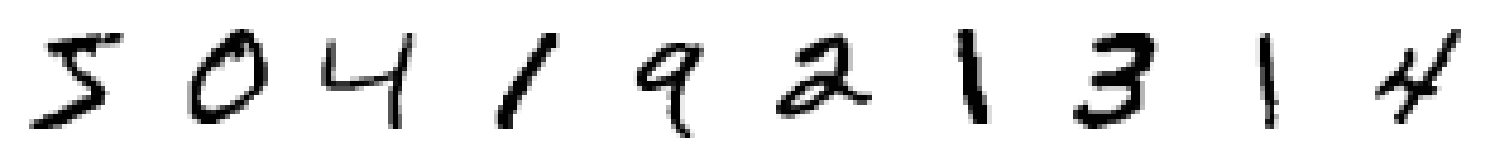

In [100]:
fig, axes = plt.subplots(1, 10, figsize=(15, 5))

for i, ax in enumerate(axes):
    digit_image = X_train[i].reshape(28,28)
    ax.imshow(digit_image,cmap="binary")
    ax.axis("off")


plt.tight_layout()
plt.show()

In [101]:
X_train.shape

(60000, 784)

## Creating my own nerual network

In [102]:
class Hidden_Layer:
    def __init__(self,n_inputs,n_neurons):
        # we already have weight matrix in it's transposed form
        self.weights = np.random.randn(n_inputs,n_neurons) * 0.01
        # initial biase values are zeros 
        self.biases = np.zeros((1,n_neurons))

    def forward(self,inputs):
        self.inputs = inputs
        self.output = np.dot(self.inputs,self.weights)+self.biases
    def backward(self,dinputs):
        self.dweights = np.dot(self.inputs.T,dinputs)
        self.dbiases = np.sum(dinputs,axis=0,keepdims=True)
        # we are taking gradients of inputs as well so that we can pass these gradients to layers before current layer
        self.dinputs = np.dot(dinputs,self.weights.T)
        
    def see_weights(self):
        print(self.weights)
    def see_biases(self):
        print(self.biases)
        

In [103]:
inputs = np.array([[1,2],
                  [2,3]])
layer1 = Hidden_Layer(2,3)
layer1.forward(inputs)

layer1.see_weights()
layer1.see_biases()
print("\n output: \n",layer1.output)

[[ 0.0188502   0.01083769  0.01320504]
 [-0.0093993  -0.00172577 -0.00943505]]
[[0. 0. 0.]]

 output: 
 [[ 5.16072423e-05  7.38615574e-03 -5.66505472e-03]
 [ 9.50251060e-03  1.64980770e-02 -1.89506207e-03]]


In [104]:
dinputs = [[0.3,0.1,0.2],
          [0.4,0.5,0.9]]
layer1.backward(dinputs)
print("\ndweights: \n",layer1.dweights)
print("\ndbiases: \n",layer1.dbiases)


dweights: 
 [[1.1 1.1 2. ]
 [1.8 1.7 3.1]]

dbiases: 
 [[0.7 0.6 1.1]]


In [105]:
class ReLU:
    def forward(self,inputs):
        # print(inputs)
        self.inputs=inputs
        self.output = np.maximum(self.inputs,0)
    def backward(self,dinputs):
        self.dinputs = dinputs.copy()
        self.dinputs[self.inputs <=0 ] =  0
    

In [106]:
activation = ReLU()

activation.forward(layer1.output)
activation.output

array([[5.16072423e-05, 7.38615574e-03, 0.00000000e+00],
       [9.50251060e-03, 1.64980770e-02, 0.00000000e+00]])

In [107]:
class Softmax:
    def forward(self,inputs):
        self.inputs = inputs
        exponents = np.exp(inputs-np.max(inputs,axis=1,keepdims = True))
        self.output = exponents/np.sum(exponents,axis=1,keepdims=True)


In [108]:
class Categorical_Cross_Entropy_Loss:
    def forward(self,y_pred,y_true):
        y_pred_clipped = np.clip(y_pred,1e-7,1-1e-7)
        
        if len(y_true.shape) == 2:
            y_true = np.argmax(y_true,axis = 1)
  
        output_length = len(y_pred_clipped)
        self.output = np.mean(-np.log(y_pred_clipped[range(output_length),y_true]))

        


        

In [109]:
y_true = np.array([[1,0],[0,1]])
y_predict = np.array([[0.6,0.1],[0.5,0.2]])
loss = Categorical_Cross_Entropy_Loss()
loss.forward(y_predict,y_true)
print(loss.output)

1.0601317681000455


In [110]:
# there is a direct derivative formula from Entropy loss to Softmax because for softmax alone the deriviation is hard 
class Softmax_Categorical_Cross_Entropy_Loss:
    def __init__(self):
        self.softmax = Softmax()
        self.loss = Categorical_Cross_Entropy_Loss()
        
    def forward(self,inputs,y_true):
        self.inputs = inputs
        self.softmax.forward(inputs)
        self.output = self.softmax.output
        self.loss.forward(self.output,y_true)
        return self.loss.output

    def backward(self,predicted,y_true):
        samples = len(predicted)
        labels = len(predicted[0])
        if len(y_true.shape) == 1:
             y_true = np.eye(labels)[y_true]
        self.dinputs = (predicted-y_true)/samples
        

In [111]:
a = np.array([[0.7,0.1],
          [0.4,0.2]])
b = np.array([[1,0],
              [0,1]])
loss = Softmax_Categorical_Cross_Entropy_Loss()
loss.backward(a,b)
loss.dinputs

array([[-0.15,  0.05],
       [ 0.2 , -0.4 ]])

In [112]:
class GD_Obtimizer:
    def __init__(self,learning_rate = 1,decay = 0):
        self.learning_rate = learning_rate
        self.current_rate = self.learning_rate
        self.decay = decay
        self.iterations = 0

    def pre_update_params(self):
        if self.decay:
            self.current_rate = self.learning_rate * (1/(1+self.decay * self.iterations))

    def update_params(self,layer):
        layer.weights = layer.weights - self.current_rate * layer.dweights
        layer.biases = layer.biases - self.current_rate * layer.dbiases

    def post_update_params(self):
        self.iterations += 1
   

In [116]:


layer1 = Hidden_Layer(784,64)
activation1 = ReLU()
output_layer = Hidden_Layer(64,10)
softmax_cross_Entropy = Softmax_Categorical_Cross_Entropy_Loss()
optimizer = GD_Obtimizer(decay=1e-3)
epochs = 100

for epoch in range(epochs):

    layer1.forward(X_train)
    activation1.forward(layer1.output)
    output_layer.forward(activation1.output)
    loss = softmax_cross_Entropy.forward(output_layer.output,y_train)
    
    predictions = np.argmax(softmax_cross_Entropy.output,axis=1)
    if len(y_train.shape) == 2:
        y_train = np.argmax(y_train,axis=1)
    accuracy = np.mean(y_train==predictions)
    print(f"epoch: {epoch}, loss: {loss}, acc: {accuracy}")
    
    
    softmax_cross_Entropy.backward(softmax_cross_Entropy.output,y_train)
    output_layer.backward(softmax_cross_Entropy.dinputs)
    activation1.backward(output_layer.dinputs)
    layer1.backward(activation1.dinputs)

    optimizer.pre_update_params()
    optimizer.update_params(layer1)
    optimizer.update_params(output_layer)
    optimizer.post_update_params()

epoch: 0, loss: 2.3019420918273896, acc: 0.109
epoch: 1, loss: 2.2962872105971126, acc: 0.368
epoch: 2, loss: 2.287630303339745, acc: 0.43156666666666665
epoch: 3, loss: 2.2710199458788356, acc: 0.4424666666666667
epoch: 4, loss: 2.238953955880589, acc: 0.41226666666666667
epoch: 5, loss: 2.1795648142216804, acc: 0.41151666666666664
epoch: 6, loss: 2.078942205577294, acc: 0.4683333333333333
epoch: 7, loss: 1.9259646766182534, acc: 0.5664833333333333
epoch: 8, loss: 1.7171450864960651, acc: 0.6273
epoch: 9, loss: 1.4760237317174887, acc: 0.6757333333333333
epoch: 10, loss: 1.2585157046704136, acc: 0.7081333333333333
epoch: 11, loss: 1.1293041891276128, acc: 0.70535
epoch: 12, loss: 1.5327927889899853, acc: 0.5459
epoch: 13, loss: 2.8769284921738376, acc: 0.22128333333333333
epoch: 14, loss: 2.064208451269356, acc: 0.42075
epoch: 15, loss: 1.8201266530603089, acc: 0.3016333333333333
epoch: 16, loss: 1.561853532474707, acc: 0.4574
epoch: 17, loss: 1.394255720136488, acc: 0.477233333333333

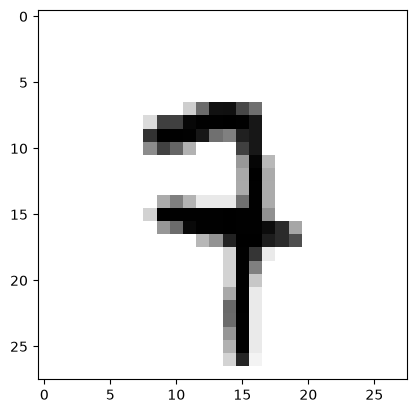

[9]


In [158]:
digit = X_test[1012]
plt.imshow(digit.reshape(28,28),cmap="binary")
plt.show()
layer1.forward(digit)
activation1.forward(layer1.output)
output_layer.forward(activation1.output)

activation2=Softmax()
activation2.forward(output_layer.output)

print(np.argmax(activation2.output,axis=1))